# Airbnb Booking Rate Prediction – Model Selection Notebook

This notebook documents a structured set of experiments designed to explore, evaluate, and compare a wide range of modeling approaches for predicting high booking rates on Airbnb listings.

Through iterative testing — including baseline models, neural networks, stacking ensembles, SMOTE balancing, and extensive XGBoost tuning — our goal is to systematically identify the most effective model in terms of AUC performance and generalization.

Each experiment builds on the lessons from the previous one, emphasizing both feature engineering and model robustness.


In [28]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt


from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

import warnings 
warnings.filterwarnings("ignore", category=UserWarning)

## Phase 1: Figuring out highest performing model families with minimum feature engineering
### Experiment 1: Baseline Model Comparison on Raw Features

In this first experiment, we work with the earliest version of our dataset:  
**`train_exp_ready_no_feature_scaling.csv`** — a lightly processed dataset containing raw numerical features, basic encoded categorical variables, and no feature scaling or advanced transformations. There were a total of 75 features which mosttly included raw features and one-hot encoded features of categorical columns (eg city, state etc). All free text columns were removed.

At this stage, our goal was not to fine-tune or engineer features, but to **scope out which model families perform best** on this problem given the basic input.

To do this, we trained four commonly used tree-based models:
- `RandomForestClassifier`
- `GradientBoostingClassifier`
- `XGBClassifier`
- `LGBMClassifier`

We used **5-fold stratified cross-validation** on an 80% train split (after reserving a 5% OOT set) and evaluated each model using **AUC** as the performance metric.

This benchmarking experiment helped us understand the relative performance of these models on the raw feature space, and provided a baseline for tracking improvement in subsequent iterations of feature engineering and model optimization.


In [5]:

# Load base dataset
df = pd.read_csv('../data/processed/train_exp_ready_no_feature_scaling.csv')
X = df.drop(columns=['high_booking_rate'])
y = df['high_booking_rate']

# Holdout 5% OOT, then 80/20 split on remaining
df_remaining, df_oot = train_test_split(df, test_size=0.05, stratify=y, random_state=42)
train_df, test_df = train_test_split(df_remaining, test_size=0.2, stratify=df_remaining['high_booking_rate'], random_state=42)
X_train = train_df.drop(columns=['high_booking_rate'])
y_train = train_df['high_booking_rate']

# Define models
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

# Run 5-fold CV
results = {}
for name, model in models.items():
    print(f"\nTraining {name}")
    aucs = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]

        auc = roc_auc_score(y_val, y_proba)
        aucs.append(auc)
        print(f"  Fold {fold+1} AUC: {auc:.4f}")
    
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    print(f"{name} Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")
    results[name] = (mean_auc, std_auc)



Training RandomForest
  Fold 1 AUC: 0.8697
  Fold 2 AUC: 0.8748
  Fold 3 AUC: 0.8763
  Fold 4 AUC: 0.8661
  Fold 5 AUC: 0.8662
RandomForest Mean AUC: 0.8706 ± 0.0043

Training GradientBoosting
  Fold 1 AUC: 0.8786
  Fold 2 AUC: 0.8830
  Fold 3 AUC: 0.8856
  Fold 4 AUC: 0.8766
  Fold 5 AUC: 0.8766
GradientBoosting Mean AUC: 0.8801 ± 0.0036

Training XGBoost
  Fold 1 AUC: 0.9012
  Fold 2 AUC: 0.9030
  Fold 3 AUC: 0.9032
  Fold 4 AUC: 0.8986
  Fold 5 AUC: 0.8974
XGBoost Mean AUC: 0.9007 ± 0.0023

Training LightGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 11347, number of negative: 44629
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003714 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2623
[LightGBM] [Info] Number of data points in the train set: 55976, number

### Model Selection: XGBoost Chosen as Primary Candidate

From our baseline experiment comparing four tree-based models, we observed that **XGBoost consistently outperformed all others** in terms of AUC:

- `XGBoost`: **0.9007 ± 0.0023**
- `LightGBM`: 0.8963 ± 0.0039
- `GradientBoosting`: 0.8801 ± 0.0036
- `RandomForest`: 0.8706 ± 0.0043

While LightGBM came close, XGBoost demonstrated both **higher mean AUC** and **lower variance**, indicating strong and stable performance out-of-the-box. Based on these results, we selected XGBoost as the **primary modeling framework** for future experimentation including hyperparameter tuning, feature engineering, and ensembling strategies.

However upon submitting this model, the test AUC came up to be only about 0.83 which suggested there is major overfitting and lack of generalization indicating the need for better Features. 


### Experiment 2: Removing Location-Based Features and running XGBoost

In this experiment, we evaluated the impact of removing **location-based features** such as `city`, and their associated one-hot encoded columns (e.g., `city_brooklyn`, `city_san francisco`, etc.). While these features provided some predictive signal, they also significantly increased the dimensionality of the dataset and risked introducing **geographical bias**.

This concern became especially important after observing a large drop in performance (**AUC ~0.85**) on a hidden test set — likely due to the model overfitting to the location distributions seen in training.

To address this, we retrained our XGBoost model **without any location indicators**, using the same hyperparameters and a clean 95/5 train-holdout split with 5-fold cross-validation on the 95%. This allowed us to assess whether the model could generalize better without relying on potentially unstable geographical cues.


In [6]:
# Load data and drop location-based features
df = pd.read_csv("../data/processed/train_exp_ready_no_feature_scaling.csv")
drop_cols = [
    'city_brooklyn', 'city_chicago', 'city_los angeles', 'city_new orleans',
    'city_new york', 'city_other', 'city_portland', 'city_san diego',
    'city_san francisco', 'city_washington'
]
df = df.drop(columns=drop_cols)

print("DATASET SHAPE : ", df.shape)

# Train-holdout split (95% train for CV, 5% final test)
train_df, holdout_df = train_test_split(
    df, test_size=0.05, stratify=df['high_booking_rate'], random_state=42
)
X = train_df.drop(columns=['high_booking_rate'])
y = train_df['high_booking_rate']
X_holdout = holdout_df.drop(columns=['high_booking_rate'])
y_holdout = holdout_df['high_booking_rate']

# 5-fold cross-validation
print("5-Fold CV with Default XGBoost (No Location Features)")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(use_label_encoder=False, eval_metric='auc', random_state=42)
    model.fit(X_train, y_train)
    y_val_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_val_proba)
    auc_scores.append(auc)
    print(f"  Fold {fold} AUC: {auc:.4f}")

print(f"Mean CV AUC: {np.mean(auc_scores):.4f}")

# Final model on full 95%, test on 5% holdout
final_model = XGBClassifier(use_label_encoder=False, eval_metric='auc', random_state=42)
final_model.fit(X, y)
y_holdout_pred = final_model.predict(X_holdout)
y_holdout_proba = final_model.predict_proba(X_holdout)[:, 1]
final_auc = roc_auc_score(y_holdout, y_holdout_proba)

print(f"\n Final Holdout AUC: {final_auc:.4f}")
print("Final Classification Report:")
print(classification_report(y_holdout, y_holdout_pred))


DATASET SHAPE :  (92067, 66)
5-Fold CV with Default XGBoost (No Location Features)
  Fold 1 AUC: 0.9032
  Fold 2 AUC: 0.9058
  Fold 3 AUC: 0.9008
  Fold 4 AUC: 0.9029
  Fold 5 AUC: 0.9042
Mean CV AUC: 0.9034

 Final Holdout AUC: 0.9039
Final Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      3671
           1       0.69      0.56      0.62       933

    accuracy                           0.86      4604
   macro avg       0.79      0.75      0.77      4604
weighted avg       0.85      0.86      0.85      4604



Results :

- **Mean CV AUC**: 0.9034  
- **Holdout AUC**: 0.9039  
- **Hidden Test AUC** (submitted): **0.83**

Despite strong internal validation, the significant drop in AUC on the hidden test set meant we needed **stronger generalization** strategies — particularly through **hyperparameter tuning**, better feature engineering, and robust cross-validation to mitigate hidden distribution shift.


## Phase 2 : Curated Feature Engineering for Diverse Model Exploration

In this phase, we transitioned from raw feature modeling to a more thoughtful and structured approach to **feature engineering**.

We conducted **extensive EDA** (as documented in the EDA notebook) to identify meaningful patterns, outliers, and correlations, and based on that analysis, we curated a **refined set of 34 features**. These features combined domain knowledge with engineering intuition and included:

- Structural listing info: `accommodates`, `bathrooms`, `bedrooms`, `beds`, `minimum_nights`
- Pricing logic: `price_per_guest`, `price_log`, `price_per_bedroom`, `extra_people_log`, `cleaning_fee_log1p`
- Availability signals: `availability_rate_30`, `availability_rate_365`, `availability_30_log`, `availability_365_log`
- Interaction features: `booking_pressure`, `price_x_avail`, `rooms_per_guest`, `lat_long_product`
- Host and listing history: `host_account_age`, `listing_age_days`, `host_listings_count_log`
- Encoded categorical/binned features: `min_night_bin`, `host_acceptance_rate_binned`, `room_type_encoded`, `property_type_encoded`, `cancellation_policy_encoded`, `bed_type_encoded`, etc.

We also explicitly handled **missing value imputation**, **log transformations**, and **intelligent binning**, laying the foundation for broader algorithm experimentation.

The goal was to prepare a dataset robust enough for:
- Non-tree models like **neural networks** that require scaling/log transformations
- Ensemble techniques like **model stacking**
- Future revisit to tree models (like XGBoost) with better feature definitions

This marked our first shift from XGBoost-specific pipelines toward **algorithm-agnostic modeling**.


### Experiment 3: Neural Network with Curated Features

Building on the 34 well-curated features created through rigorous EDA and preprocessing, we explored the use of a **neural network** for binary classification. Unlike tree-based models, neural networks benefit from **scaled and imputed data**, so we applied:

- **Median imputation** for missing values
- **StandardScaler** for normalization
- **Label smoothing** and **weighted loss** to handle class imbalance

We trained a simple multi-layer perceptron (MLP) using **PyTorch**, evaluated using **5-fold cross-validation** on 95% of the dataset, and tested on the final 5% holdout set. This experiment also included **live tracking of training loss and validation AUC**, allowing us to visualize convergence and potential overfitting.


Starting 5-Fold Cross-Validation

Fold 1
Epoch 01 | Loss: 0.9705 | Val AUC: 0.8516
Epoch 02 | Loss: 0.8867 | Val AUC: 0.8603
Epoch 03 | Loss: 0.8732 | Val AUC: 0.8624
Epoch 04 | Loss: 0.8679 | Val AUC: 0.8631
Epoch 05 | Loss: 0.8636 | Val AUC: 0.8649
Epoch 06 | Loss: 0.8594 | Val AUC: 0.8660
Epoch 07 | Loss: 0.8574 | Val AUC: 0.8666
Epoch 08 | Loss: 0.8554 | Val AUC: 0.8676
Epoch 09 | Loss: 0.8535 | Val AUC: 0.8680
Epoch 10 | Loss: 0.8524 | Val AUC: 0.8685
Epoch 11 | Loss: 0.8502 | Val AUC: 0.8686
Epoch 12 | Loss: 0.8509 | Val AUC: 0.8691
Epoch 13 | Loss: 0.8471 | Val AUC: 0.8691
Epoch 14 | Loss: 0.8486 | Val AUC: 0.8691
Epoch 15 | Loss: 0.8456 | Val AUC: 0.8694
Epoch 16 | Loss: 0.8471 | Val AUC: 0.8702
Epoch 17 | Loss: 0.8453 | Val AUC: 0.8699
Epoch 18 | Loss: 0.8461 | Val AUC: 0.8687
Epoch 19 | Loss: 0.8441 | Val AUC: 0.8703
Epoch 20 | Loss: 0.8433 | Val AUC: 0.8709
Epoch 21 | Loss: 0.8430 | Val AUC: 0.8713
Epoch 22 | Loss: 0.8422 | Val AUC: 0.8701
Epoch 23 | Loss: 0.8415 | Val AUC: 

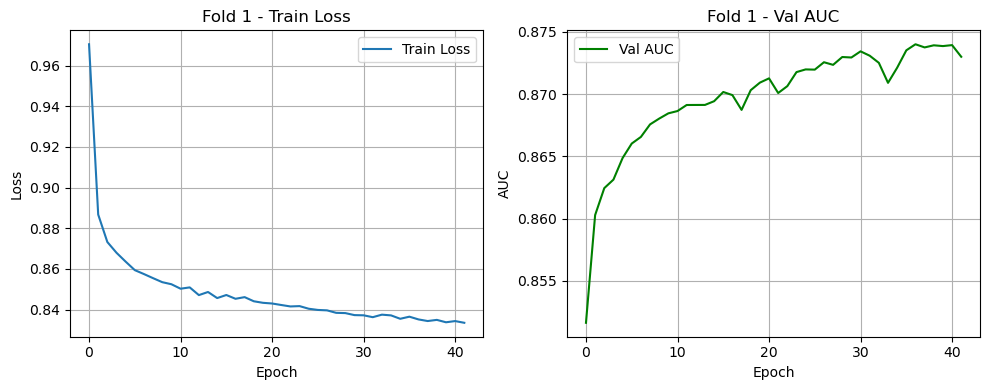

AUC for fold 1: 0.8740

Fold 2
Epoch 01 | Loss: 0.9565 | Val AUC: 0.8529
Epoch 02 | Loss: 0.8907 | Val AUC: 0.8601
Epoch 03 | Loss: 0.8747 | Val AUC: 0.8628
Epoch 04 | Loss: 0.8686 | Val AUC: 0.8641
Epoch 05 | Loss: 0.8641 | Val AUC: 0.8645
Epoch 06 | Loss: 0.8606 | Val AUC: 0.8655
Epoch 07 | Loss: 0.8605 | Val AUC: 0.8659
Epoch 08 | Loss: 0.8565 | Val AUC: 0.8670
Epoch 09 | Loss: 0.8537 | Val AUC: 0.8671
Epoch 10 | Loss: 0.8535 | Val AUC: 0.8678
Epoch 11 | Loss: 0.8527 | Val AUC: 0.8676
Epoch 12 | Loss: 0.8507 | Val AUC: 0.8682
Epoch 13 | Loss: 0.8489 | Val AUC: 0.8686
Epoch 14 | Loss: 0.8489 | Val AUC: 0.8689
Epoch 15 | Loss: 0.8478 | Val AUC: 0.8680
Epoch 16 | Loss: 0.8463 | Val AUC: 0.8695
Epoch 17 | Loss: 0.8470 | Val AUC: 0.8693
Epoch 18 | Loss: 0.8441 | Val AUC: 0.8699
Epoch 19 | Loss: 0.8439 | Val AUC: 0.8706
Epoch 20 | Loss: 0.8459 | Val AUC: 0.8708
Epoch 21 | Loss: 0.8425 | Val AUC: 0.8709
Epoch 22 | Loss: 0.8425 | Val AUC: 0.8701
Epoch 23 | Loss: 0.8422 | Val AUC: 0.8704
Epo

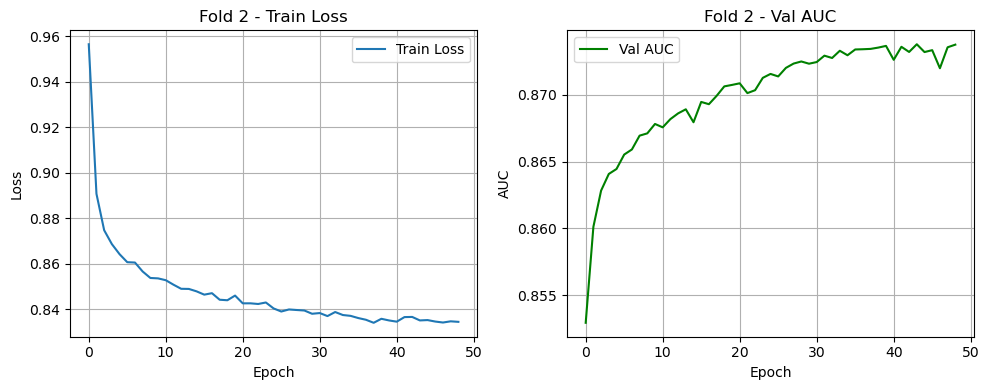

AUC for fold 2: 0.8738

Fold 3
Epoch 01 | Loss: 0.9622 | Val AUC: 0.8470
Epoch 02 | Loss: 0.8854 | Val AUC: 0.8547
Epoch 03 | Loss: 0.8719 | Val AUC: 0.8563
Epoch 04 | Loss: 0.8655 | Val AUC: 0.8568
Epoch 05 | Loss: 0.8613 | Val AUC: 0.8585
Epoch 06 | Loss: 0.8579 | Val AUC: 0.8592
Epoch 07 | Loss: 0.8566 | Val AUC: 0.8606
Epoch 08 | Loss: 0.8525 | Val AUC: 0.8607
Epoch 09 | Loss: 0.8515 | Val AUC: 0.8614
Epoch 10 | Loss: 0.8503 | Val AUC: 0.8620
Epoch 11 | Loss: 0.8479 | Val AUC: 0.8625
Epoch 12 | Loss: 0.8491 | Val AUC: 0.8626
Epoch 13 | Loss: 0.8468 | Val AUC: 0.8634
Epoch 14 | Loss: 0.8457 | Val AUC: 0.8637
Epoch 15 | Loss: 0.8456 | Val AUC: 0.8636
Epoch 16 | Loss: 0.8445 | Val AUC: 0.8632
Epoch 17 | Loss: 0.8433 | Val AUC: 0.8642
Epoch 18 | Loss: 0.8414 | Val AUC: 0.8645
Epoch 19 | Loss: 0.8414 | Val AUC: 0.8647
Epoch 20 | Loss: 0.8402 | Val AUC: 0.8648
Epoch 21 | Loss: 0.8406 | Val AUC: 0.8648
Epoch 22 | Loss: 0.8391 | Val AUC: 0.8653
Epoch 23 | Loss: 0.8387 | Val AUC: 0.8655
Epo

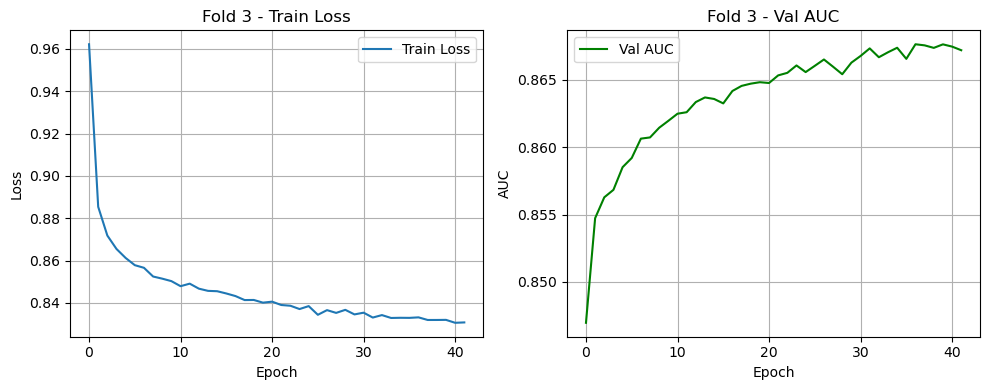

AUC for fold 3: 0.8676

Fold 4
Epoch 01 | Loss: 0.9573 | Val AUC: 0.8492
Epoch 02 | Loss: 0.8860 | Val AUC: 0.8554
Epoch 03 | Loss: 0.8745 | Val AUC: 0.8582
Epoch 04 | Loss: 0.8691 | Val AUC: 0.8593
Epoch 05 | Loss: 0.8615 | Val AUC: 0.8603
Epoch 06 | Loss: 0.8598 | Val AUC: 0.8613
Epoch 07 | Loss: 0.8574 | Val AUC: 0.8617
Epoch 08 | Loss: 0.8551 | Val AUC: 0.8625
Epoch 09 | Loss: 0.8531 | Val AUC: 0.8630
Epoch 10 | Loss: 0.8518 | Val AUC: 0.8630
Epoch 11 | Loss: 0.8511 | Val AUC: 0.8638
Epoch 12 | Loss: 0.8503 | Val AUC: 0.8640
Epoch 13 | Loss: 0.8493 | Val AUC: 0.8640
Epoch 14 | Loss: 0.8472 | Val AUC: 0.8648
Epoch 15 | Loss: 0.8471 | Val AUC: 0.8642
Epoch 16 | Loss: 0.8464 | Val AUC: 0.8655
Epoch 17 | Loss: 0.8437 | Val AUC: 0.8658
Epoch 18 | Loss: 0.8449 | Val AUC: 0.8659
Epoch 19 | Loss: 0.8442 | Val AUC: 0.8662
Epoch 20 | Loss: 0.8419 | Val AUC: 0.8655
Epoch 21 | Loss: 0.8413 | Val AUC: 0.8665
Epoch 22 | Loss: 0.8411 | Val AUC: 0.8669
Epoch 23 | Loss: 0.8395 | Val AUC: 0.8672
Epo

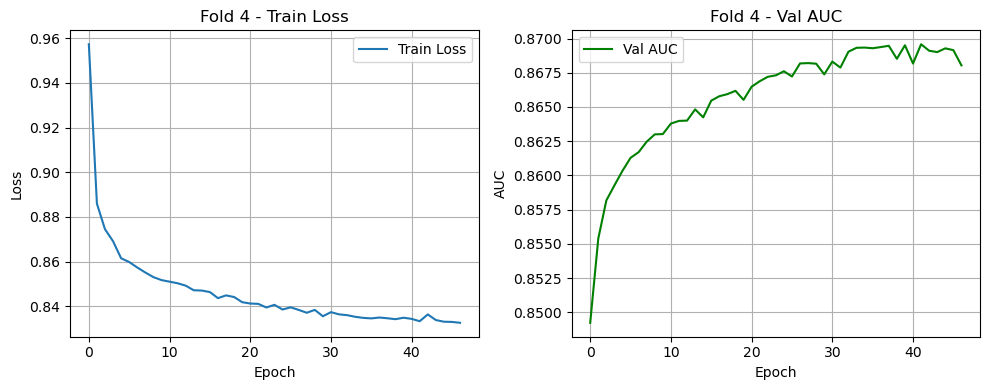

AUC for fold 4: 0.8696

Fold 5
Epoch 01 | Loss: 0.9704 | Val AUC: 0.8493
Epoch 02 | Loss: 0.8890 | Val AUC: 0.8585
Epoch 03 | Loss: 0.8752 | Val AUC: 0.8602
Epoch 04 | Loss: 0.8681 | Val AUC: 0.8617
Epoch 05 | Loss: 0.8642 | Val AUC: 0.8630
Epoch 06 | Loss: 0.8610 | Val AUC: 0.8642
Epoch 07 | Loss: 0.8572 | Val AUC: 0.8644
Epoch 08 | Loss: 0.8568 | Val AUC: 0.8649
Epoch 09 | Loss: 0.8560 | Val AUC: 0.8655
Epoch 10 | Loss: 0.8540 | Val AUC: 0.8660
Epoch 11 | Loss: 0.8525 | Val AUC: 0.8658
Epoch 12 | Loss: 0.8506 | Val AUC: 0.8661
Epoch 13 | Loss: 0.8499 | Val AUC: 0.8669
Epoch 14 | Loss: 0.8493 | Val AUC: 0.8673
Epoch 15 | Loss: 0.8457 | Val AUC: 0.8677
Epoch 16 | Loss: 0.8489 | Val AUC: 0.8677
Epoch 17 | Loss: 0.8453 | Val AUC: 0.8676
Epoch 18 | Loss: 0.8460 | Val AUC: 0.8682
Epoch 19 | Loss: 0.8456 | Val AUC: 0.8683
Epoch 20 | Loss: 0.8425 | Val AUC: 0.8686
Epoch 21 | Loss: 0.8433 | Val AUC: 0.8686
Epoch 22 | Loss: 0.8429 | Val AUC: 0.8689
Epoch 23 | Loss: 0.8432 | Val AUC: 0.8696
Epo

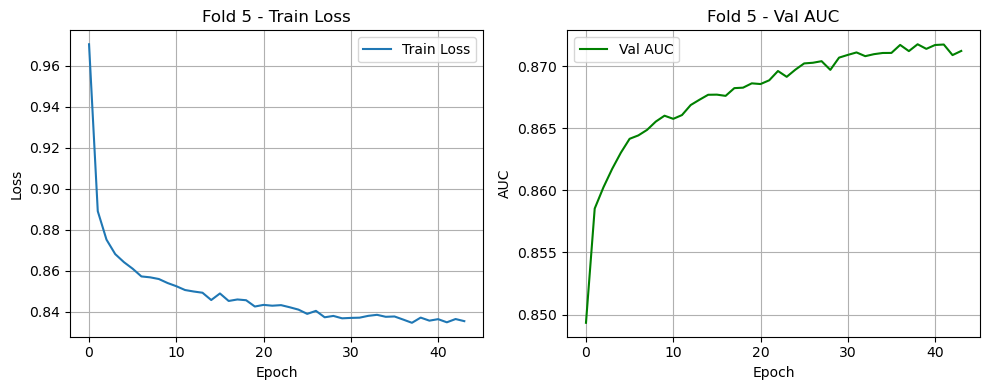

AUC for fold 5: 0.8718

Mean CV AUC: 0.8714
Epoch 01 | Loss: 0.9555 | Val AUC: 0.8466
Epoch 02 | Loss: 0.8820 | Val AUC: 0.8514
Epoch 03 | Loss: 0.8713 | Val AUC: 0.8532
Epoch 04 | Loss: 0.8636 | Val AUC: 0.8550
Epoch 05 | Loss: 0.8612 | Val AUC: 0.8556
Epoch 06 | Loss: 0.8579 | Val AUC: 0.8564
Epoch 07 | Loss: 0.8554 | Val AUC: 0.8595
Epoch 08 | Loss: 0.8531 | Val AUC: 0.8584
Epoch 09 | Loss: 0.8518 | Val AUC: 0.8581
Epoch 10 | Loss: 0.8509 | Val AUC: 0.8606
Epoch 11 | Loss: 0.8492 | Val AUC: 0.8606
Epoch 12 | Loss: 0.8483 | Val AUC: 0.8616
Epoch 13 | Loss: 0.8481 | Val AUC: 0.8611
Epoch 14 | Loss: 0.8466 | Val AUC: 0.8617
Epoch 15 | Loss: 0.8446 | Val AUC: 0.8624
Epoch 16 | Loss: 0.8441 | Val AUC: 0.8631
Epoch 17 | Loss: 0.8422 | Val AUC: 0.8624
Epoch 18 | Loss: 0.8417 | Val AUC: 0.8640
Epoch 19 | Loss: 0.8409 | Val AUC: 0.8641
Epoch 20 | Loss: 0.8396 | Val AUC: 0.8648
Epoch 21 | Loss: 0.8389 | Val AUC: 0.8641
Epoch 22 | Loss: 0.8391 | Val AUC: 0.8651
Epoch 23 | Loss: 0.8382 | Val AU

In [15]:
# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 50
BATCH_SIZE = 512
PATIENCE = 5
LR = 1e-3
LABEL_SMOOTHING = 0.05
POS_WEIGHT = 4.0

# Label Smoothing
def smooth_bce(targets, smoothing=0.05):
    return targets * (1 - smoothing) + 0.5 * smoothing

# Load and preprocess data
df = pd.read_csv("../data/processed/train_data_new_1.csv")
X = df.drop(columns=["high_booking_rate"])
y = df["high_booking_rate"].values

X = SimpleImputer(strategy="median").fit_transform(X)
X = StandardScaler().fit_transform(X)

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.05, stratify=y, random_state=42
)

# MLP definition
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

# Training function
def train_model(X_train, y_train, X_val, y_val, input_dim, fold=None):
    model = MLP(input_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT], device=DEVICE))

    train_loader = DataLoader(TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32)
    ), batch_size=BATCH_SIZE, shuffle=True)

    val_loader = DataLoader(TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32)
    ), batch_size=BATCH_SIZE, shuffle=False)

    best_auc = 0
    best_weights = None
    patience = 0
    train_losses = []
    val_aucs = []

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = smooth_bce(yb, LABEL_SMOOTHING).to(DEVICE)
            optimizer.zero_grad()
            preds = model(xb).squeeze()
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        all_preds, all_targets = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                logits = model(xb).squeeze()
                probs = torch.sigmoid(logits).cpu().numpy()
                all_preds.extend(probs)
                all_targets.extend(yb.numpy())
        auc = roc_auc_score(all_targets, all_preds)
        val_aucs.append(auc)

        print(f"Epoch {epoch+1:02d} | Loss: {train_loss:.4f} | Val AUC: {auc:.4f}")

        if auc > best_auc:
            best_auc = auc
            best_weights = model.state_dict()
            patience = 0
        else:
            patience += 1
            if patience >= PATIENCE:
                break

    model.load_state_dict(best_weights)

    if fold is not None:
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label="Train Loss")
        plt.title(f"Fold {fold} - Train Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(val_aucs, label="Val AUC", color="green")
        plt.title(f"Fold {fold} - Val AUC")
        plt.xlabel("Epoch")
        plt.ylabel("AUC")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return model, best_auc

# Cross-validation
print("Starting 5-Fold Cross-Validation")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f"\nFold {fold}")
    model, auc = train_model(X_train[train_idx], y_train[train_idx],
                             X_train[val_idx], y_train[val_idx],
                             input_dim=X_train.shape[1], fold=fold)
    auc_scores.append(auc)
    print(f"AUC for fold {fold}: {auc:.4f}")

print(f"\nMean CV AUC: {np.mean(auc_scores):.4f}")

# Final evaluation on holdout set
final_model, _ = train_model(X_train, y_train, X_holdout, y_holdout, X_train.shape[1])
final_model.eval()
with torch.no_grad():
    logits = final_model(torch.tensor(X_holdout, dtype=torch.float32).to(DEVICE)).squeeze()
    y_pred = torch.sigmoid(logits).cpu().numpy()

holdout_auc = roc_auc_score(y_holdout, y_pred)
print(f"\nFinal Holdout AUC: {holdout_auc:.4f}")

### Neural Network – Performance Plateau and Discontinuation

In this experiment, we trained a feedforward neural network (MLP) on the curated dataset with 34 features. Despite several iterations involving changes in architecture (number of layers, hidden units), adding dropout, and adjusting learning strategies, the neural network consistently plateaued around a **holdout AUC of 0.88**, with no runs surpassing this mark.

This led us to discontinue neural network experimentation.

A key insight came from our EDA: many features with missing values showed **non-random patterns**, where missingness correlated with booking behavior. However, since neural networks require complete data, we had applied **median imputation** across all features. This strategy likely diluted meaningful signal carried by missingness and introduced noise, limiting the network’s ability to capture deeper patterns.

In contrast, tree-based models like XGBoost naturally handle missing values and can implicitly learn from missingness as a split criterion — giving them an advantage in this problem setting.


### Experiment 4: Multi-Model Stacking for AUC Boost

After observing diminishing returns with standalone models like XGBoost and neural networks, we explored **multi-model stacking** to improve generalization.

Stacking combines the predictions of multiple diverse base models (e.g., tree-based models, linear models, ensemble methods) and feeds them into a **meta-learner**, which learns to correct individual model weaknesses and leverage complementary strengths.

Theoretically, stacking can **reduce bias and variance simultaneously**, helping improve metrics like AUC — especially when individual models capture different aspects of the data distribution.

In our setup, we trained multiple base models using 5-fold cross-validation and collected their out-of-fold predictions to form a new feature matrix. A separate **meta-model** (typically logistic regression) was then trained on this stacked representation to make the final prediction.

This architecture aims to **better generalize on unseen data** by learning from the collective behavior of diverse models, and ideally outperform any single base learner.


In [18]:
# --- Baseline Model Configurations  ---
MODEL_CONFIG = {
    "extratrees": {
        "model_type": "sklearn",
        "class": "ExtraTreesClassifier",
        "params": {"n_estimators": 300, "max_depth": 8, "random_state": 42}
    },
    "xgb_1": {
        "model_type": "xgb",
        "params": {"use_label_encoder": False, "eval_metric": "logloss", "random_state": 42,
                   "colsample_bytree": 0.9, "learning_rate": 0.01, "max_depth": 9,
                   "n_estimators": 2000, "subsample": 0.8, "scale_pos_weight": 2}
    },
    "xgb_2": {
        "model_type": "xgb",
        "params": {"max_depth": 6, "learning_rate": 0.05, "n_estimators": 1000,
                   "subsample": 0.8, "colsample_bytree": 0.8, "scale_pos_weight": 4}
    },
    "xgb_3": {
        "model_type": "xgb",
        "params": {"max_depth": 7, "learning_rate": 0.03, "n_estimators": 800,
                   "subsample": 0.9, "colsample_bytree": 0.6, "scale_pos_weight": 4}
    },
    "logreg": {
        "model_type": "sklearn",
        "class": "LogisticRegression",
        "params": {"solver": "saga", "max_iter": 1000, "class_weight": "balanced"}
    },
    "rf": {
        "model_type": "sklearn",
        "class": "RandomForestClassifier",
        "params": {"n_estimators": 300, "max_depth": 7, "class_weight": "balanced", "random_state": 42}
    },
    "lgb": {
        "model_type": "lgb",
        "params": {"n_estimators": 500, "learning_rate": 0.05, "scale_pos_weight": 4,
                   "random_state": 42, "verbose": -1}
    },
    "cat": {
        "model_type": "catboost",
        "params": {"iterations": 500, "learning_rate": 0.05, "depth": 6, "verbose": 0, "scale_pos_weight": 4}
    },
    "adaboost": {
        "model_type": "sklearn",
        "class": "AdaBoostClassifier",
        "params": {"n_estimators": 300, "learning_rate": 0.1, "random_state": 42}
    },
    "knn": {
        "model_type": "sklearn",
        "class": "KNeighborsClassifier",
        "params": {"n_neighbors": 20, "weights": "distance"}
    }
}


In [22]:
# --- Utility Functions ---
def split_train_holdout(df, target, test_size=0.25):
    return train_test_split(df, test_size=test_size, stratify=df[target], random_state=42)

def load_model(name, cfg):
    model_type = cfg['model_type']
    if model_type == 'xgb': return XGBClassifier(**cfg['params'])
    if model_type == 'lgb': return LGBMClassifier(**cfg['params'])
    if model_type == 'catboost': return CatBoostClassifier(**cfg['params'])
    if model_type == 'sklearn': return eval(cfg['class'])(**cfg['params'])
    raise ValueError(f"Unknown model type: {model_type}")

def run_base_models(X, y, config_dict, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    meta_df = pd.DataFrame(index=X.index)
    meta_df['high_booking_rate'] = y

    for name, cfg in config_dict.items():
        print(f"Training base model: {name}")
        oof_pred = np.zeros(len(X))
        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
            model = load_model(name, cfg)
            model.fit(X.iloc[train_idx], y[train_idx])
            probas = model.predict_proba(X.iloc[val_idx])[:, 1]
            oof_pred[val_idx] = probas
            print(f"  Fold {fold+1} AUC: {roc_auc_score(y[val_idx], probas):.4f}")
        print(f"  Mean OOF AUC for {name}: {roc_auc_score(y, oof_pred):.4f}\n")
        meta_df[name] = oof_pred
    return meta_df

def train_meta_model(X_meta, y_meta):
    print("Training Meta-Model (Logistic Regression)")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X_meta))
    aucs = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_meta, y_meta)):
        model = LogisticRegression(max_iter=1000)
        model.fit(X_meta.iloc[train_idx], y_meta.iloc[train_idx])
        probs = model.predict_proba(X_meta.iloc[val_idx])[:, 1]
        oof_preds[val_idx] = probs
        auc = roc_auc_score(y_meta[val_idx], probs)
        aucs.append(auc)
        print(f"Fold {fold+1} AUC: {auc:.4f}")
    print(f"Mean CV AUC (Meta-Model): {np.mean(aucs):.4f}\n")
    final_model = LogisticRegression(max_iter=1000)
    final_model.fit(X_meta, y_meta)
    return final_model

def evaluate_on_holdout(holdout_df, config_dict, meta_model, n_folds=5):
    y_true = holdout_df['high_booking_rate'].values
    X_holdout = holdout_df.drop(columns=['high_booking_rate'])
    X_holdout = pd.DataFrame(StandardScaler().fit_transform(X_holdout), columns=X_holdout.columns)

    meta_features = pd.DataFrame(index=holdout_df.index)
    for name, cfg in config_dict.items():
        preds = np.zeros(len(X_holdout))
        for fold in range(n_folds):
            model = load_model(name, cfg)
            model.fit(X_holdout, y_true)  # simulate as if retrained
            preds += model.predict_proba(X_holdout)[:, 1] / n_folds
        meta_features[name] = preds

    y_pred = meta_model.predict_proba(meta_features)[:, 1]
    auc = roc_auc_score(y_true, y_pred)
    print(f"Final Holdout AUC (Stacked): {auc:.4f}")

# --- Main Execution ---
if __name__ == "__main__":
    df = pd.read_csv("../data/processed/train_data_new_1.csv")
    train_df, holdout_df = split_train_holdout(df, target="high_booking_rate", test_size=0.25)

    X_train = train_df.drop(columns=["high_booking_rate"])
    y_train = train_df["high_booking_rate"].values
    X_train = pd.DataFrame(StandardScaler().fit_transform(X_train), columns=X_train.columns)

    meta_df = run_base_models(X_train, y_train, config_dict=MODEL_CONFIG)
    X_meta = meta_df.drop(columns=["high_booking_rate"])
    y_meta = meta_df["high_booking_rate"]
    meta_model = train_meta_model(X_meta, y_meta)

    evaluate_on_holdout(holdout_df, config_dict=MODEL_CONFIG, meta_model=meta_model)



Training base model: extratrees
  Fold 1 AUC: 0.8548
  Fold 2 AUC: 0.8548
  Fold 3 AUC: 0.8513
  Fold 4 AUC: 0.8550
  Fold 5 AUC: 0.8544
  Mean OOF AUC for extratrees: 0.8540

Training base model: xgb_1
  Fold 1 AUC: 0.8944
  Fold 2 AUC: 0.8929
  Fold 3 AUC: 0.8927
  Fold 4 AUC: 0.8996
  Fold 5 AUC: 0.8930
  Mean OOF AUC for xgb_1: 0.8945

Training base model: xgb_2
  Fold 1 AUC: 0.8930
  Fold 2 AUC: 0.8908
  Fold 3 AUC: 0.8893
  Fold 4 AUC: 0.8971
  Fold 5 AUC: 0.8893
  Mean OOF AUC for xgb_2: 0.8919

Training base model: xgb_3
  Fold 1 AUC: 0.8931
  Fold 2 AUC: 0.8914
  Fold 3 AUC: 0.8914
  Fold 4 AUC: 0.8973
  Fold 5 AUC: 0.8905
  Mean OOF AUC for xgb_3: 0.8927

Training base model: logreg
  Fold 1 AUC: 0.8528
  Fold 2 AUC: 0.8532
  Fold 3 AUC: 0.8502
  Fold 4 AUC: 0.8557
  Fold 5 AUC: 0.8514
  Mean OOF AUC for logreg: 0.8526

Training base model: rf
  Fold 1 AUC: 0.8550
  Fold 2 AUC: 0.8528
  Fold 3 AUC: 0.8484
  Fold 4 AUC: 0.8517
  Fold 5 AUC: 0.8501
  Mean OOF AUC for rf: 0.8514

### Multi-Model Stacking – Overfitting Case Study

In this experiment, we implemented a **multi-model stacking** strategy combining 10 diverse base learners — including variants of XGBoost, LightGBM, CatBoost, Random Forest, ExtraTrees, Logistic Regression, KNN, AdaBoost, etc. The out-of-fold predictions from these base models were used as inputs to a **Logistic Regression meta-model**, trained to blend their outputs for better generalization.

**Base Model Highlights**:
- Best AUCs came from XGBoost models (~0.8945), followed by LightGBM and CatBoost.
- Weaker models (e.g., KNN, AdaBoost) still contributed to diversity.

**Meta-Model Results**:
- **CV AUC (5-fold on meta-dataset)**: 0.8942
- **Holdout AUC (25% unseen)**: 0.9985 ← *suspiciously high*
- **Hidden Test AUC (submitted)**: 0.422 ← *catastrophic failure*

This experiment clearly exposed a **severe overfitting issue**.

While internal cross-validation was reasonable, the meta-model completely overfit to the holdout set — likely memorizing patterns from out-of-fold predictions rather than learning generalizable rules. The extremely high holdout AUC misled us, and the sharp collapse on the hidden test set confirmed that the model had lost all generalization power.

> **Key takeaway**: Stacking must be used with caution — especially when combining many models of varying strength. Meta-features should be carefully regularized, and more robust stacking architectures or constraints may be necessary to prevent overfitting to ensemble noise.


### Experiment 5: Handling Class Imbalance with SMOTE

After a catastrophic failure with model stacking, we went back to our baseline XGBoost model (not yet hyper-parameter tuned).

It is around this point, we thought of addressing the the issue of class imbalance. Our dataset exhibited a significant class imbalance — with **79.7% of listings labeled as class 0** (low booking rate) and only **20.3% as class 1** (high booking rate). This imbalance was suspected to be a contributing factor to our models plateauing in performance, particularly in recall and overall AUC.

To address this, we re-evaluated our baseline **XGBoost model** but this time applied **SMOTE (Synthetic Minority Over-sampling Technique)** to the training data before model fitting. SMOTE synthetically generates new instances of the minority class by interpolating between existing observations, thus balancing the dataset more naturally compared to manual class weighting.

The goal of this experiment was to investigate whether SMOTE could help improve model sensitivity and AUC by ensuring the classifier is exposed to a more balanced decision boundary during training.


In [24]:
# --- Load Data ---
df = pd.read_csv("../data/processed/train_data_new_1.csv")
X = df.drop(columns=["high_booking_rate"])
y = df["high_booking_rate"]

# --- Split into 75% train (with CV) and 25% holdout ---
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# --- Standardize Features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_holdout_scaled = scaler.transform(X_holdout)

# --- Apply SMOTE ---
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train_scaled, y_train)

# --- Cross-Validation ---
print("Starting 5-Fold CV with XGBoost + SMOTE")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_smote, y_train_smote), 1):
    X_tr, X_val = X_train_smote[train_idx], X_train_smote[val_idx]
    y_tr, y_val = y_train_smote.iloc[train_idx], y_train_smote.iloc[val_idx]

    model = XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        colsample_bytree=0.9,
        learning_rate=0.05,
        max_depth=6,
        n_estimators=1000,
        subsample=0.8,
        scale_pos_weight=1
    )

    model.fit(X_tr, y_tr)
    preds = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds)
    auc_scores.append(auc)
    print(f"  Fold {fold} AUC: {auc:.4f}")

print(f"\nMean CV AUC: {np.mean(auc_scores):.4f}")

# --- Final Evaluation on Holdout ---
final_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    colsample_bytree=0.9,
    learning_rate=0.05,
    max_depth=6,
    n_estimators=1000,
    subsample=0.8,
    scale_pos_weight=1
)
final_model.fit(X_train_smote, y_train_smote)

holdout_proba = final_model.predict_proba(X_holdout_scaled)[:, 1]
holdout_auc = roc_auc_score(y_holdout, holdout_proba)
print(f"\nFinal Holdout AUC: {holdout_auc:.4f}")

holdout_preds = final_model.predict(X_holdout_scaled)
print("\nFinal Classification Report:")
print(classification_report(y_holdout, holdout_preds))

Starting 5-Fold CV with XGBoost + SMOTE
  Fold 1 AUC: 0.9727
  Fold 2 AUC: 0.9742
  Fold 3 AUC: 0.9739
  Fold 4 AUC: 0.9741
  Fold 5 AUC: 0.9733

Mean CV AUC: 0.9736

Final Holdout AUC: 0.8951

Final Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91     18351
           1       0.67      0.56      0.61      4666

    accuracy                           0.85     23017
   macro avg       0.78      0.75      0.76     23017
weighted avg       0.85      0.85      0.85     23017



### SMOTE with XGBoost – Overfitting Due to Oversampling

We trained a default XGBoost model with SMOTE-applied data and observed the following:

- **5-Fold CV AUC**: 0.9736  
- **Final Holdout AUC**: 0.8951  
- **Precision/Recall (class 1)**: Precision = 0.67, Recall = 0.56

Despite an extremely high AUC during cross-validation, the model **underperformed on the holdout set**, indicating **clear overfitting**.

#### Why did this happen?

- SMOTE generates synthetic samples by interpolating existing minority class instances. While useful in theory, it can **inflate the training distribution** with **highly similar or noisy synthetic points**, causing the model to learn overly optimistic decision boundaries.
- XGBoost is a high-capacity learner, and when trained on artificially balanced data, it may **overfit to synthetic patterns** not present in real-world distributions.
- Since SMOTE was only applied on the training folds and not the holdout set, there was a **distributional mismatch** between what the model learned and what it encountered during final evaluation.

> **Key takeaway**: While SMOTE improved cross-validation AUC dramatically, it led to poor generalization. This suggests that synthetic balancing techniques should be applied with caution, especially when combined with complex classifiers like XGBoost. Handling imbalance via smarter feature engineering or class weighting may yield better real-world performance.


## Phase 3 – Hyperparameter Tuning and Finalizing the Model  
### Experiment 6: XGBoost + Bayesian Hyperparameter Optimization

In this phase, we returned to XGBoost — now armed with deeper insights from earlier experiments — and focused on two major directions:

1. **Substantial feature engineering improvements**
2. **Extensive hyperparameter tuning using Bayesian optimization via Weights & Biases sweeps**

---

#### Feature Engineering Enhancements

To unlock further gains, we redesigned the dataset with more refined and meaningful features:

**1. Sentiment scores from previously unused free text columns**  
Free text fields like `description`, `summary`, `house_rules`, `host_about`, and `neighborhood_overview` were parsed using sentiment analysis tools. The resulting sentiment scores (positive/neutral/negative) were introduced as numerical features.

**2. First-level logical interaction features**  
We engineered intuitive domain-driven features such as:

- `price_per_accommodate`  
- `cleaning_fee_to_price`  
- `availability_ratio`  
- `high_cleaning_fee_flag`, `long_term_availability_flag`  
- `bathrooms_per_guest`, `price_per_bedroom`  
- `booking_pressure` for listings unavailable year-round

**3. Second-level (advanced) interaction features**  
We pushed interaction logic further by capturing cross-feature relationships:

- Sentiment × price combinations: `desc_sentiment_price`, `summary_sentiment_price`  
- Normalized sentiment: `desc_sentiment_per_accommodate`, etc.  
- Availability vs price: `availability_price_ratio`  
- Flag-based logic: `superhost_high_cleaning`, `is_fast_response_premium`, `is_luxury_property`

**4. Missing value strategy**  
Instead of aggressively imputing missing values, we preserved most `NaN`s. XGBoost is known to naturally handle missing values during split decisions, and our EDA showed that missingness itself often carried signal — especially in fields like security deposit, host_about, and host_response_time.

---

#### Hyperparameter Search Space (Bayesian Optimization with W&B)

To tune the XGBoost classifier effectively, we defined a comprehensive search space and used **Bayesian optimization** (via Weights & Biases Sweeps) to efficiently explore high-performing configurations. The optimization goal was to **maximize validation AUC (`val_auc`)**.

Below is the list of hyperparameters and their candidate values:

- `n_estimators`: [500, 800, 1000, 1500, 2000, 2500, 3000]  
- `learning_rate`: [0.01, 0.03, 0.05, 0.1]  
- `max_depth`: [3, 4, 5, 6, 7, 9]  
- `subsample`: [0.8, 0.9, 1.0]  
- `colsample_bytree`: [0.8, 0.9, 1.0]  
- `scale_pos_weight`: [2.0, 2.5, 3.0, 3.5, 4.0]  
- `gamma`: [0, 1, 3, 5]  
- `min_child_weight`: [1, 3, 5, 7]  

The search was driven using:

- **method**: `bayes` (Bayesian optimization)  
- **metric**: `val_auc`  
- **goal**: `maximize`

This setup enabled us to strike a balance between **exploration and exploitation**, efficiently converging to hyperparameter configurations that maximized model generalization.


Models were evaluated not just on **AUC**, but also on **F1 score** to ensure balanced performance on the imbalanced classification task.

> The final tuned XGBoost model was chosen based on its ability to perform well across both cross-validation and the unseen holdout set — representing our best balance between precision, recall, and generalization at this stage.


In [25]:
# Load dataset
df = pd.read_csv("../data/processed/train_data_new_v7.csv")
train_df, holdout_df = train_test_split(
    df, test_size=0.05, stratify=df['high_booking_rate'], random_state=42
)

X = train_df.drop(columns=['high_booking_rate'])
y = train_df['high_booking_rate']
X_holdout = holdout_df.drop(columns=['high_booking_rate'])
y_holdout = holdout_df['high_booking_rate']

# Cross-validation
print("Starting 5-Fold CV with XGBoost (balmy-sweep-50)")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(
        use_label_encoder=False,
        eval_metric='auc',
        random_state=42,
        colsample_bytree=0.8,
        learning_rate=0.01,
        max_depth=9,
        n_estimators=3500,
        subsample=0.8,
        scale_pos_weight=1.5,
        gamma=0,
        min_child_weight=1
    )
    model.fit(X_train, y_train)
    y_val_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_val_proba)
    auc_scores.append(auc)
    print(f"  Fold {fold} AUC: {auc:.4f}")

print(f"\nMean CV AUC: {np.mean(auc_scores):.4f}")

# Final evaluation on holdout
final_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    colsample_bytree=0.8,
    learning_rate=0.01,
    max_depth=9,
    n_estimators=3500,
    subsample=0.8,
    scale_pos_weight=1.5,
    gamma=0,
    min_child_weight=1
)
final_model.fit(X, y)
y_holdout_pred = final_model.predict(X_holdout)
y_holdout_proba = final_model.predict_proba(X_holdout)[:, 1]

print(f"\nFinal Holdout AUC: {roc_auc_score(y_holdout, y_holdout_proba):.4f}")
print("\nFinal Classification Report:")
print(classification_report(y_holdout, y_holdout_pred))

Starting 5-Fold CV with XGBoost (balmy-sweep-50)
  Fold 1 AUC: 0.9153
  Fold 2 AUC: 0.9173
  Fold 3 AUC: 0.9134
  Fold 4 AUC: 0.9124
  Fold 5 AUC: 0.9150

Mean CV AUC: 0.9147

Final Holdout AUC: 0.9141

Final Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      3671
           1       0.69      0.62      0.66       933

    accuracy                           0.87      4604
   macro avg       0.80      0.78      0.79      4604
weighted avg       0.86      0.87      0.87      4604



## Final Model Summary – balmy-sweep-50

After extensive experimentation across multiple modeling strategies, feature engineering techniques, and tuning procedures, the final tuned XGBoost model (`balmy-sweep-50`) achieved the best balance between performance and generalization.

**Results:**
- **Mean CV AUC**: 0.9147
- **Final Holdout AUC**: 0.9141
- **F1 Score (Class 1)**: 0.66

This model successfully integrates advanced domain-informed features, sentiment signals, and fine-tuned hyperparameters — making it our **final selected model** for submission and deployment.
